# stagev7 result audit

Display-only notebook for a completed stagev7 run. It reads existing CSV, JSON, Markdown, and PNG artifacts only. It does **not** train models, extract E/M/L features, call APIs, fit pipelines, or modify result metrics.

## 1. Project and path resolution

In [1]:
from __future__ import annotations

import asyncio
import json
import os
import sys
from pathlib import Path

if sys.platform.startswith("win") and hasattr(asyncio, "WindowsSelectorEventLoopPolicy"):
    asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

import pandas as pd
from IPython.display import Image, Markdown, display


def resolve_root() -> Path:
    """Find stagev7 from project root, notebooks/, or an explicitly supplied environment variable."""
    env_root = os.environ.get('STAGEV7_ROOT')
    candidates = []
    if env_root:
        candidates.append(Path(env_root).expanduser())
    cwd = Path.cwd().resolve()
    candidates.extend([cwd, *cwd.parents])
    for candidate in candidates:
        candidate = candidate.resolve()
        if (candidate / 'run_stagev7.py').exists() and (candidate / 'output').exists():
            return candidate
    raise RuntimeError(
        'Cannot locate the stagev7 project root. Open this notebook from the stagev7 project, '
        'or set STAGEV7_ROOT to the absolute stagev7 directory before launching Jupyter.'
    )


ROOT = resolve_root()
OUTPUT = ROOT / 'output'
FINAL = OUTPUT / 'final_report'
CHECKS = OUTPUT / 'checks'
FIG = FINAL / 'figures'

IDENTITY = pd.DataFrame([
    {
        'project': 'stagev7',
        'task': 'Hierarchical stage classification plus AD-versus-control output',
        'decision_path': 'late → middle → early-spectrum AD vs control',
        'feature_policy': 'Strictly existing stagev5 E/M/L CSVs',
        'CV protocol': '10-fold stratified CV within each gate',
        'primary cascade': 'C06 (pre-specified)',
        'external ranking status': 'Exploratory comparison only',
        'project_root': str(ROOT),
        'final_report_dir': str(FINAL),
    }
])
display(IDENTITY)

,project,task,decision_path,feature_policy,CV protocol,primary cascade,external ranking status,project_root,final_report_dir
0,stagev7,Hierarchical stage classification plus AD-vers...,late → middle → early-spectrum AD vs control,Strictly existing stagev5 E/M/L CSVs,10-fold stratified CV within each gate,C06 (pre-specified),Exploratory comparison only,D:\research\H.L.Liang-Lab\Code\expore\stagev7,D:\research\H.L.Liang-Lab\Code\expore\stagev7\...


In [2]:
def artifact_path(name: str, area: str = 'final') -> Path:
    base = {'final': FINAL, 'checks': CHECKS, 'figures': FIG}[area]
    return base / name


def read_csv(name: str, *, required_columns: list[str] | None = None) -> pd.DataFrame:
    path = artifact_path(name)
    if not path.exists():
        display(Markdown(f'**Not generated yet:** `{path.relative_to(ROOT)}`'))
        return pd.DataFrame()
    try:
        table = pd.read_csv(path)
    except Exception as exc:
        display(Markdown(f'**Could not read:** `{path.relative_to(ROOT)}` — `{type(exc).__name__}: {exc}`'))
        return pd.DataFrame()
    if required_columns:
        missing = [c for c in required_columns if c not in table.columns]
        if missing:
            display(Markdown(f'**Unexpected schema in** `{path.relative_to(ROOT)}`. Missing columns: `{missing}`'))
    return table


def read_json(name: str, *, area: str = 'final') -> dict:
    path = artifact_path(name, area)
    if not path.exists():
        display(Markdown(f'**Not generated yet:** `{path.relative_to(ROOT)}`'))
        return {}
    try:
        return json.loads(path.read_text(encoding='utf-8'))
    except Exception as exc:
        display(Markdown(f'**Could not read:** `{path.relative_to(ROOT)}` — `{type(exc).__name__}: {exc}`'))
        return {}


def show_md(name: str) -> None:
    path = artifact_path(name)
    if path.exists():
        display(Markdown(path.read_text(encoding='utf-8')))
    else:
        display(Markdown(f'**Not generated yet:** `{path.relative_to(ROOT)}`'))


def show_png(name: str, title: str) -> None:
    path = artifact_path(name, 'figures')
    if path.exists():
        display(Markdown(f'### {title}'))
        display(Image(filename=str(path)))
    else:
        display(Markdown(f'**Figure not generated yet:** `{path.relative_to(ROOT)}`'))


def display_existing_columns(table: pd.DataFrame, columns: list[str], n: int = 30) -> None:
    if table.empty:
        return
    available = [c for c in columns if c in table.columns]
    if available:
        display(table.loc[:, available].head(n))
    else:
        display(table.head(n))

## 2. Input and feature-source audit

In [3]:
check = read_json('stagev7_self_check.json', area='checks')
if check:
    display(pd.json_normalize(check))

manifest = read_json('stagev7_feature_source_manifest.json')
if manifest:
    summary = {
        'E feature count': manifest.get('feature_counts', {}).get('E'),
        'M feature count': manifest.get('feature_counts', {}).get('M'),
        'L feature count': manifest.get('feature_counts', {}).get('L'),
        'E policy': manifest.get('E_policy'),
        'M policy': manifest.get('M_policy'),
        'L policy': manifest.get('L_policy'),
        'No new extraction': manifest.get('no_new_extraction'),
    }
    display(pd.DataFrame([summary]))
else:
    display(Markdown('Run `python run_stagev7.py --mode train ...` before reviewing final feature provenance.'))

,status,created_at,n_train,n_external,no_api_or_feature_extraction,feature_counts.E,feature_counts.M,feature_counts.L,train_original_stage_counts.control,train_original_stage_counts.middle,...,feature_files.ad.L_file,feature_files.ad.n,feature_files.control.E_file,feature_files.control.M_file,feature_files.control.L_file,feature_files.control.n,feature_files.test.E_file,feature_files.test.M_file,feature_files.test.L_file,feature_files.test.n
0,pass,2026-06-21T11:16:14.760813+00:00,166,71,True,61,1024,8,79,50,...,D:\research\H.L.Liang-Lab\Code\expore\stagev7\...,87,D:\research\H.L.Liang-Lab\Code\expore\stagev7\...,D:\research\H.L.Liang-Lab\Code\expore\stagev7\...,D:\research\H.L.Liang-Lab\Code\expore\stagev7\...,79,D:\research\H.L.Liang-Lab\Code\expore\stagev7\...,D:\research\H.L.Liang-Lab\Code\expore\stagev7\...,D:\research\H.L.Liang-Lab\Code\expore\stagev7\...,71


,E feature count,M feature count,L feature count,E policy,M policy,L policy,No new extraction
0,61,1024,8,stagev5 copied stagev2 BM25 features,stagev5 copied stagev2 BGE-M3 window embedding...,stagev5 copied stagev4 unmasked raw F8 only,True


## 3. Final-report availability

In [4]:
expected = [
    'stagev7_late_gate_model_ranking.csv',
    'stagev7_middle_gate_model_ranking.csv',
    'stagev7_early_gate_model_ranking.csv',
    'stagev7_gate_model_ranking_all.csv',
    'stagev7_cascade_ranking_external_exploratory.csv',
    'stagev7_final_cascade_predictions.csv',
    'stagev7_final_primary_performance.csv',
    'stagev7_final_confusion_matrix_binary.csv',
    'stagev7_final_confusion_matrix_stage_collapsed.csv',
    'stagev7_final_stage_strict_audit.csv',
    'stagev7_gate_path_audit.csv',
    'stagev7_cascade_error_analysis.csv',
    'stagev7_bootstrap_ci.csv',
    'stagev7_flat_multiclass_baseline_performance.csv',
    'stagev7_feature_source_manifest.json',
    'stagev7_leakage_check.json',
    'stagev7_final_run_summary.json',
    'stagev7_selected_model_summary.md',
    'stagev7_experiment_report.md',
]
availability = pd.DataFrame([
    {'artifact': name, 'available': artifact_path(name).exists(), 'path': str(artifact_path(name).relative_to(ROOT))}
    for name in expected
])
display(availability)

,artifact,available,path
0,stagev7_late_gate_model_ranking.csv,True,output\final_report\stagev7_late_gate_model_ra...
1,stagev7_middle_gate_model_ranking.csv,True,output\final_report\stagev7_middle_gate_model_...
2,stagev7_early_gate_model_ranking.csv,True,output\final_report\stagev7_early_gate_model_r...
3,stagev7_gate_model_ranking_all.csv,True,output\final_report\stagev7_gate_model_ranking...
4,stagev7_cascade_ranking_external_exploratory.csv,True,output\final_report\stagev7_cascade_ranking_ex...
5,stagev7_final_cascade_predictions.csv,True,output\final_report\stagev7_final_cascade_pred...
6,stagev7_final_primary_performance.csv,True,output\final_report\stagev7_final_primary_perf...
7,stagev7_final_confusion_matrix_binary.csv,True,output\final_report\stagev7_final_confusion_ma...
8,stagev7_final_confusion_matrix_stage_collapsed...,True,output\final_report\stagev7_final_confusion_ma...
9,stagev7_final_stage_strict_audit.csv,True,output\final_report\stagev7_final_stage_strict...


## 4. Gate-level CV model audit

,gate,model_key,family,feature_block,cv_best_balanced_accuracy,best_params
11,early,EM__lr__elasticnet,LR-elasticnet,EM,0.876190,"{""clf__C"": 1.0, ""clf__class_weight"": ""balanced..."
12,early,EM__mlp__small,MLP-small,EM,0.844940,"{""clf__alpha"": 0.0001, ""clf__hidden_layer_size..."
13,early,EM__svc__linear,Linear-SVC,EM,0.801190,"{""clf__C"": 0.1, ""clf__class_weight"": ""balanced""}"
14,early,EM__svc__poly3,SVC-poly3,EM,0.727083,"{""clf__C"": 0.1, ""clf__class_weight"": ""balanced..."
15,early,EM__svc__poly2,SVC-poly2,EM,0.719940,"{""clf__C"": 1.0, ""clf__class_weight"": ""balanced..."
16,early,E__lr__l2,LR-L2,E,0.708333,"{""clf__C"": 0.1, ""clf__class_weight"": ""balanced""}"
17,early,EM__svc__rbf,SVC-RBF,EM,0.708333,"{""clf__C"": 1.0, ""clf__class_weight"": ""balanced..."
0,late,EML__lr__elasticnet,LR-elasticnet,EML,0.665000,"{""clf__C"": 0.1, ""clf__class_weight"": ""balanced..."
1,late,ML__lr__l2,LR-L2,ML,0.615000,"{""clf__C"": 1.0, ""clf__class_weight"": ""balanced""}"
2,late,ML__svc__linear,Linear-SVC,ML,0.545000,"{""clf__C"": 0.1, ""clf__class_weight"": ""balanced""}"


**Highest 10-fold CV balanced-accuracy candidate per gate**

,gate,model_key,family,feature_block,cv_best_balanced_accuracy,best_params
0,early,EM__lr__elasticnet,LR-elasticnet,EM,0.87619,"{""clf__C"": 1.0, ""clf__class_weight"": ""balanced..."
1,late,EML__lr__elasticnet,LR-elasticnet,EML,0.66500,"{""clf__C"": 0.1, ""clf__class_weight"": ""balanced..."
2,middle,M__lr__l2,LR-L2,M,0.73500,"{""clf__C"": 0.1, ""clf__class_weight"": ""balanced""}"


### Best CV model by gate

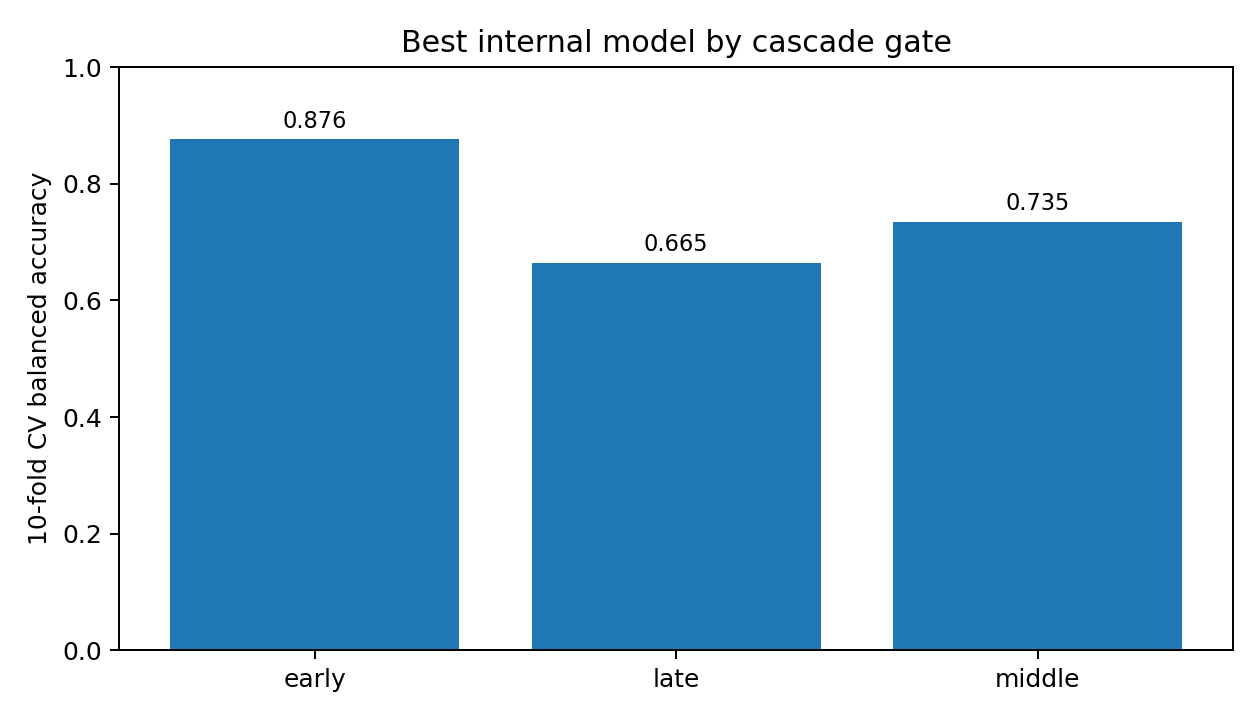

In [5]:
gate_ranking = read_csv('stagev7_gate_model_ranking_all.csv', required_columns=['gate', 'model_key', 'cv_best_balanced_accuracy'])
if not gate_ranking.empty:
    display_existing_columns(
        gate_ranking.sort_values(['gate', 'cv_best_balanced_accuracy'], ascending=[True, False]),
        ['gate', 'model_key', 'family', 'feature_block', 'cv_best_balanced_accuracy', 'cv_oof_accuracy', 'cv_oof_sensitivity', 'cv_oof_specificity', 'cv_oof_pr_auc', 'best_params'],
        n=60,
    )
    best_gate = (gate_ranking.sort_values('cv_best_balanced_accuracy', ascending=False)
                 .groupby('gate', as_index=False).first())
    display(Markdown('**Highest 10-fold CV balanced-accuracy candidate per gate**'))
    display_existing_columns(best_gate, ['gate', 'model_key', 'family', 'feature_block', 'cv_best_balanced_accuracy', 'best_params'])
show_png('fig01_gate_best_cv_balanced_accuracy.png', 'Best CV model by gate')

## 5. Primary pre-specified cascade: C06

In [6]:
primary_perf = read_csv('stagev7_final_primary_performance.csv')
if not primary_perf.empty:
    display(primary_perf)
show_md('stagev7_selected_model_summary.md')

primary_pred = read_csv(
    'stagev7_final_cascade_predictions.csv',
    required_columns=['sample_id', 'true_collapsed_stage_label', 'predicted_stage', 'disease_label', 'predicted_AD'],
)
if not primary_pred.empty:
    display_existing_columns(
        primary_pred,
        ['sample_id', 'true_original_stage_label', 'true_collapsed_stage_label', 'predicted_stage', 'disease_label', 'predicted_AD', 'decision_path', 'ad_path_score', 'binary_correct', 'stage_correct_collapsed'],
        n=20,
    )

,accuracy,balanced_accuracy,sensitivity,specificity,f1,precision,mcc,roc_auc,pr_auc,brier,tn,fp,fn,tp,stage_accuracy,stage_balanced_accuracy,stage_macro_f1,stage_weighted_f1
0,0.71831,0.718651,0.742857,0.694444,0.722222,0.702703,0.437649,0.718651,0.648768,0.28169,25,11,9,26,0.422535,0.316468,0.282258,0.415785


# Stagev7 selected primary cascade

**Primary cascade (pre-specified):** C06.
**Late gate:** `ML__lr__l2`; **middle gate:** `EM__svc__poly3`; **early-spectrum gate:** `EM__svc__poly3`.
Late, middle, and early-spectrum predictions all map to AD=1; control maps to AD=0.
`AD_high_MMSE` is retained for strict audit but joins early at the final early-spectrum gate, not relabelled as strict early.
External ranking of all pre-specified cascades is exploratory and must not be reported as an external-test model-selection procedure.


,sample_id,true_original_stage_label,true_collapsed_stage_label,predicted_stage,disease_label,predicted_AD,decision_path,ad_path_score,binary_correct,stage_correct_collapsed
0,TEST_0001,late,late,late,1,1,late_positive,0.996028,1,1
1,TEST_0002,late,late,middle,1,1,late_negative__middle_positive,0.941120,1,0
2,TEST_0003,control,control,control,0,0,late_negative__middle_negative__control,0.648516,1,1
3,TEST_0004,late,late,middle,1,1,late_negative__middle_positive,0.887132,1,0
4,TEST_0005,control,control,late,0,1,late_positive,0.951007,0,0
5,TEST_0006,control,control,control,0,0,late_negative__middle_negative__control,0.496879,1,1
6,TEST_0007,control,control,control,0,0,late_negative__middle_negative__control,0.463073,1,1
7,TEST_0008,middle,middle,late,1,1,late_positive,0.985150,1,0
8,TEST_0009,control,control,control,0,0,late_negative__middle_negative__control,0.441297,1,1
9,TEST_0010,late,late,middle,1,1,late_negative__middle_positive,0.848760,1,0


## 6. External binary and stage confusion matrices

,disease_label,0,1
0,0,25,11
1,1,9,26


,true_collapsed_stage_label,control,early_spectrum_AD,middle,late
0,control,25,4,2,5
1,early_spectrum_AD,5,0,9,0
2,middle,4,2,2,6
3,late,0,0,4,3


### Primary C06 collapsed-stage confusion matrix

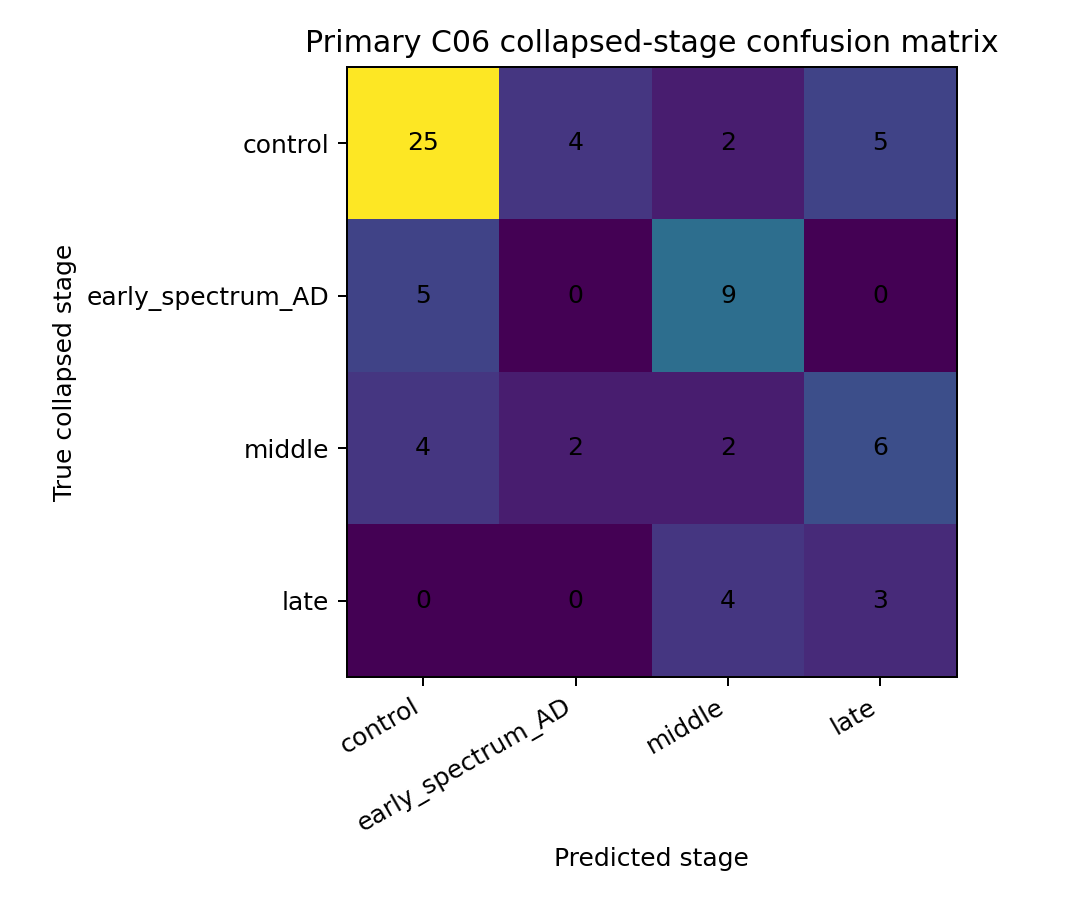

In [7]:
binary_cm = read_csv('stagev7_final_confusion_matrix_binary.csv')
if not binary_cm.empty:
    display(binary_cm)

stage_cm = read_csv('stagev7_final_confusion_matrix_stage_collapsed.csv')
if not stage_cm.empty:
    display(stage_cm)

show_png('fig03_primary_stage_confusion_matrix.png', 'Primary C06 collapsed-stage confusion matrix')

## 7. Bootstrap confidence intervals for C06

,metric,estimate,ci_low,ci_high,bootstrap_n
0,accuracy,0.718310,0.619366,0.816901,200
1,balanced_accuracy,0.718651,0.619987,0.816569,200
2,sensitivity,0.742857,0.600000,0.885940,200
3,specificity,0.694444,0.564063,0.838836,200
4,f1,0.722222,0.596423,0.813999,200
6,mcc,0.437649,0.240520,0.622432,200
14,stage_accuracy,0.422535,0.323944,0.549296,200
15,stage_balanced_accuracy,0.316468,0.201264,0.436223,200
16,stage_macro_f1,0.282258,0.200306,0.366852,200
9,brier,0.281690,0.183099,0.380634,200


### Primary C06 external bootstrap confidence intervals

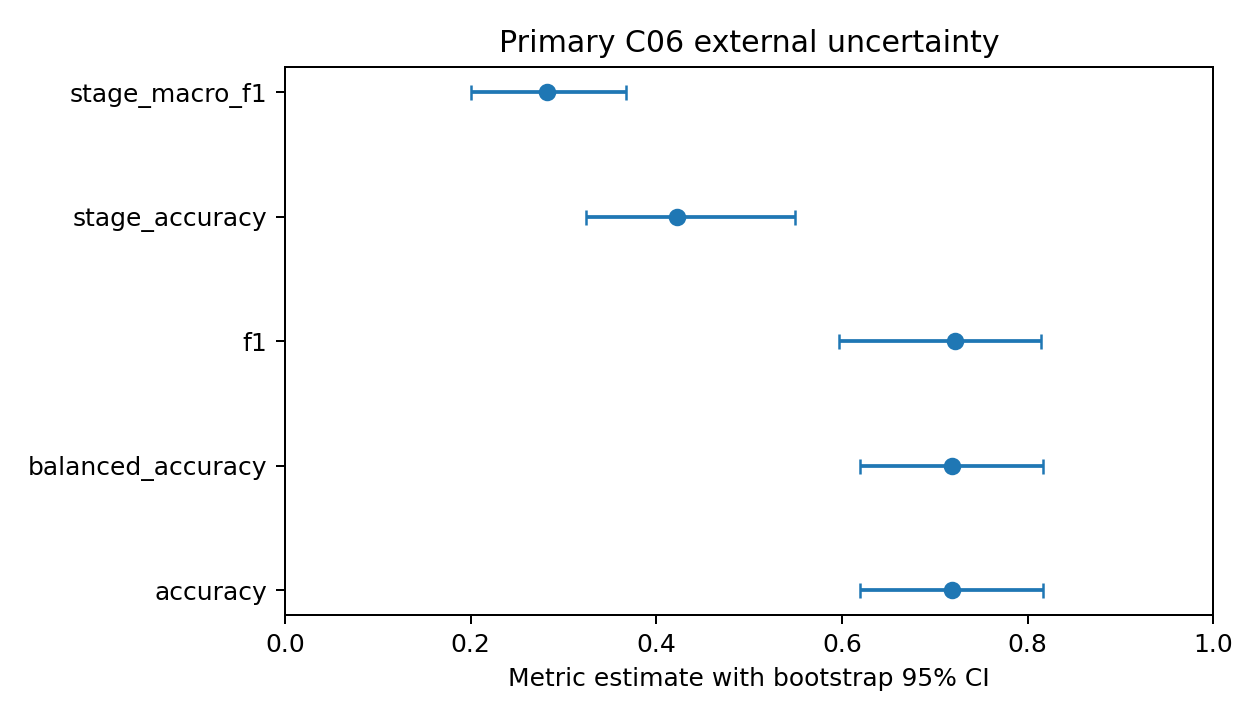

In [8]:
boot = read_csv('stagev7_bootstrap_ci.csv', required_columns=['metric', 'estimate', 'ci_low', 'ci_high'])
if not boot.empty:
    preferred = ['accuracy', 'balanced_accuracy', 'sensitivity', 'specificity', 'f1', 'mcc', 'stage_accuracy', 'stage_balanced_accuracy', 'stage_macro_f1']
    ordered = boot.copy()
    ordered['_order'] = ordered['metric'].map({m: i for i, m in enumerate(preferred)}).fillna(len(preferred))
    display(ordered.sort_values(['_order', 'metric']).drop(columns='_order'))
show_png('fig05_primary_bootstrap_ci.png', 'Primary C06 external bootstrap confidence intervals')

## 8. Fixed cascade comparison — exploratory only

**Interpretation restriction:** this table compares multiple pre-specified systems on the same held-out external set. It is exploratory and does not replace C06 as the primary model.

,cascade_id,late_component,middle_component,early_component,binary_accuracy,binary_balanced_accuracy,binary_sensitivity,binary_specificity,binary_f1,binary_mcc,stage_accuracy,stage_macro_f1
0,C16,ML__svc__rbf,EM__svc__rbf,EM__svc__rbf,0.774648,0.773413,0.685714,0.861111,0.750000,0.556174,0.535211,0.288462
1,C15,ML__lr__l2,EM__svc__rbf,EM__svc__rbf,0.760563,0.760714,0.771429,0.750000,0.760563,0.521429,0.464789,0.308444
2,C19,ML__lr__l2,EML__svc__poly3,EM__lr__elasticnet,0.746479,0.748016,0.857143,0.638889,0.769231,0.507436,0.436620,0.337991
3,C18,EML__lr__elasticnet,EML__svc__poly3,EM__svc__poly3,0.746479,0.745635,0.685714,0.805556,0.727273,0.495216,0.563380,0.453467
4,C05,ML__lr__l2,EM__lr__elasticnet,EM__lr__elasticnet,0.732394,0.734524,0.885714,0.583333,0.765432,0.490968,0.408451,0.329418
5,C14,EML__lr__elasticnet,EM__svc__poly3,EM__svc__poly3,0.732394,0.731349,0.657143,0.805556,0.707692,0.468307,0.549296,0.436211
6,C17,ML__svc__rbf,EM__svc__poly3,EM__svc__poly3,0.732394,0.731349,0.657143,0.805556,0.707692,0.468307,0.492958,0.267259
7,C10,EML__lr__elasticnet,EM__lr__elasticnet,EM__svc__linear,0.718310,0.719048,0.771429,0.666667,0.729730,0.440196,0.521127,0.471066
8,C06,ML__lr__l2,EM__svc__poly3,EM__svc__poly3,0.718310,0.718651,0.742857,0.694444,0.722222,0.437649,0.422535,0.282258
9,C13,ML__svc__linear,EM__svc__poly2,EM__svc__poly3,0.718310,0.717857,0.685714,0.750000,0.705882,0.436755,0.492958,0.362022


### Exploratory predefined cascade comparison

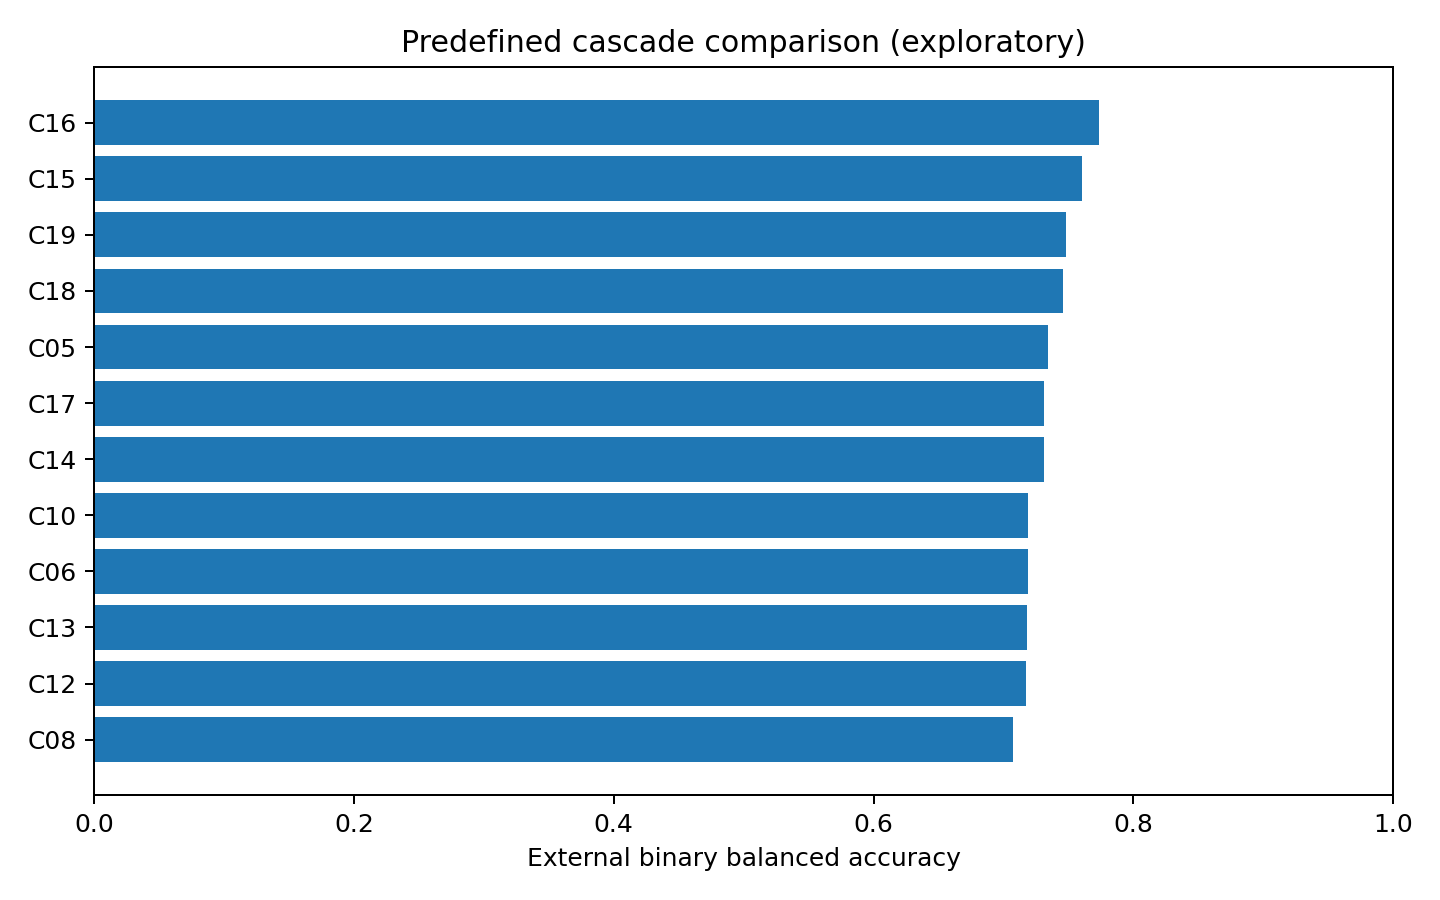

In [9]:
cascade_rank = read_csv('stagev7_cascade_ranking_external_exploratory.csv', required_columns=['cascade_id', 'binary_balanced_accuracy'])
if not cascade_rank.empty:
    display(Markdown('**Interpretation restriction:** this table compares multiple pre-specified systems on the same held-out external set. It is exploratory and does not replace C06 as the primary model.'))
    display_existing_columns(
        cascade_rank,
        ['cascade_id', 'late_component', 'middle_component', 'early_component', 'binary_accuracy', 'binary_balanced_accuracy', 'binary_sensitivity', 'binary_specificity', 'binary_f1', 'binary_mcc', 'stage_accuracy', 'stage_macro_f1'],
        n=25,
    )
show_png('fig02_cascade_external_comparison_exploratory.png', 'Exploratory predefined cascade comparison')

## 9. Flat multiclass baselines

In [10]:
baseline = read_csv('stagev7_flat_multiclass_baseline_performance.csv')
if not baseline.empty:
    display_existing_columns(
        baseline.sort_values('stage_macro_f1', ascending=False) if 'stage_macro_f1' in baseline.columns else baseline,
        ['baseline_id', 'feature_block', 'cv_best_balanced_accuracy', 'accuracy', 'balanced_accuracy', 'f1', 'mcc', 'stage_accuracy', 'stage_balanced_accuracy', 'stage_macro_f1', 'best_params'],
        n=10,
    )

,baseline_id,feature_block,cv_best_balanced_accuracy,accuracy,balanced_accuracy,f1,mcc,stage_accuracy,stage_balanced_accuracy,stage_macro_f1,best_params
0,B1_multinomial_lr_EML,EML,0.488958,0.802817,0.803968,0.815789,0.615306,0.507042,0.394841,0.389479,"{""clf__C"": 0.1, ""clf__class_weight"": ""balanced""}"
1,B2_multinomial_lr_EM,EM,0.485833,0.774648,0.775794,0.789474,0.558273,0.478873,0.370040,0.368390,"{""clf__C"": 0.1, ""clf__class_weight"": ""balanced""}"
2,B3_svc_rbf_EML,EML,0.350804,0.774648,0.775794,0.789474,0.558273,0.535211,0.423611,0.358157,"{""clf__C"": 1.0, ""clf__class_weight"": ""balanced..."
3,B4_svc_poly3_EM,EM,0.436875,0.802817,0.802778,0.800000,0.605556,0.549296,0.379960,0.317668,"{""clf__C"": 1.0, ""clf__class_weight"": ""balanced..."


## 10. Stage, path, and error audit

**Strict audit retains `AD_high_MMSE` rather than relabelling it as strict early.**

,true_original_stage_label,predicted_stage,n
0,AD_high_MMSE,control,3
1,AD_high_MMSE,middle,5
2,control,control,25
3,control,early_spectrum_AD,4
4,control,late,5
5,control,middle,2
6,early,control,2
7,early,middle,4
8,late,late,3
9,late,middle,4


,decision_path,n,binary_accuracy,stage_accuracy
0,late_negative__middle_negative__control,34,0.735294,0.735294
1,late_negative__middle_negative__early_spectrum...,6,0.333333,0.000000
2,late_negative__middle_positive,17,0.882353,0.117647
3,late_positive,14,0.642857,0.214286


,sample_id,true_original_stage_label,true_collapsed_stage_label,predicted_stage,disease_label,predicted_AD,decision_path,late_gate_score,middle_gate_score_given_nonlate,early_spectrum_gate_score_given_nonlate_nonmiddle,ad_path_score,binary_correct,stage_correct_collapsed
0,TEST_0002,late,late,middle,1,1,late_negative__middle_positive,0.224705,0.808733,0.602940,0.941120,1,0
1,TEST_0004,late,late,middle,1,1,late_negative__middle_positive,0.379866,0.670928,0.446913,0.887132,1,0
2,TEST_0005,control,control,late,0,1,late_positive,0.883555,0.390846,0.309315,0.951007,0,0
3,TEST_0008,middle,middle,late,1,1,late_positive,0.909600,0.634758,0.550249,0.985150,1,0
4,TEST_0010,late,late,middle,1,1,late_negative__middle_positive,0.136969,0.594287,0.568063,0.848760,1,0
5,TEST_0011,AD_high_MMSE,early_spectrum_AD,middle,1,1,late_negative__middle_positive,0.025195,0.534915,0.330736,0.696577,1,0
6,TEST_0012,early,early_spectrum_AD,middle,1,1,late_negative__middle_positive,0.047267,0.586582,0.538883,0.818377,1,0
7,TEST_0014,early,early_spectrum_AD,middle,1,1,late_negative__middle_positive,0.199396,0.624732,0.444513,0.833109,1,0
8,TEST_0016,middle,middle,control,1,0,late_negative__middle_negative__control,0.054370,0.497043,0.381123,0.705655,0,0
9,TEST_0017,middle,middle,control,1,0,late_negative__middle_negative__control,0.443794,0.392571,0.336780,0.775927,0,0


### Primary C06 subgroup performance

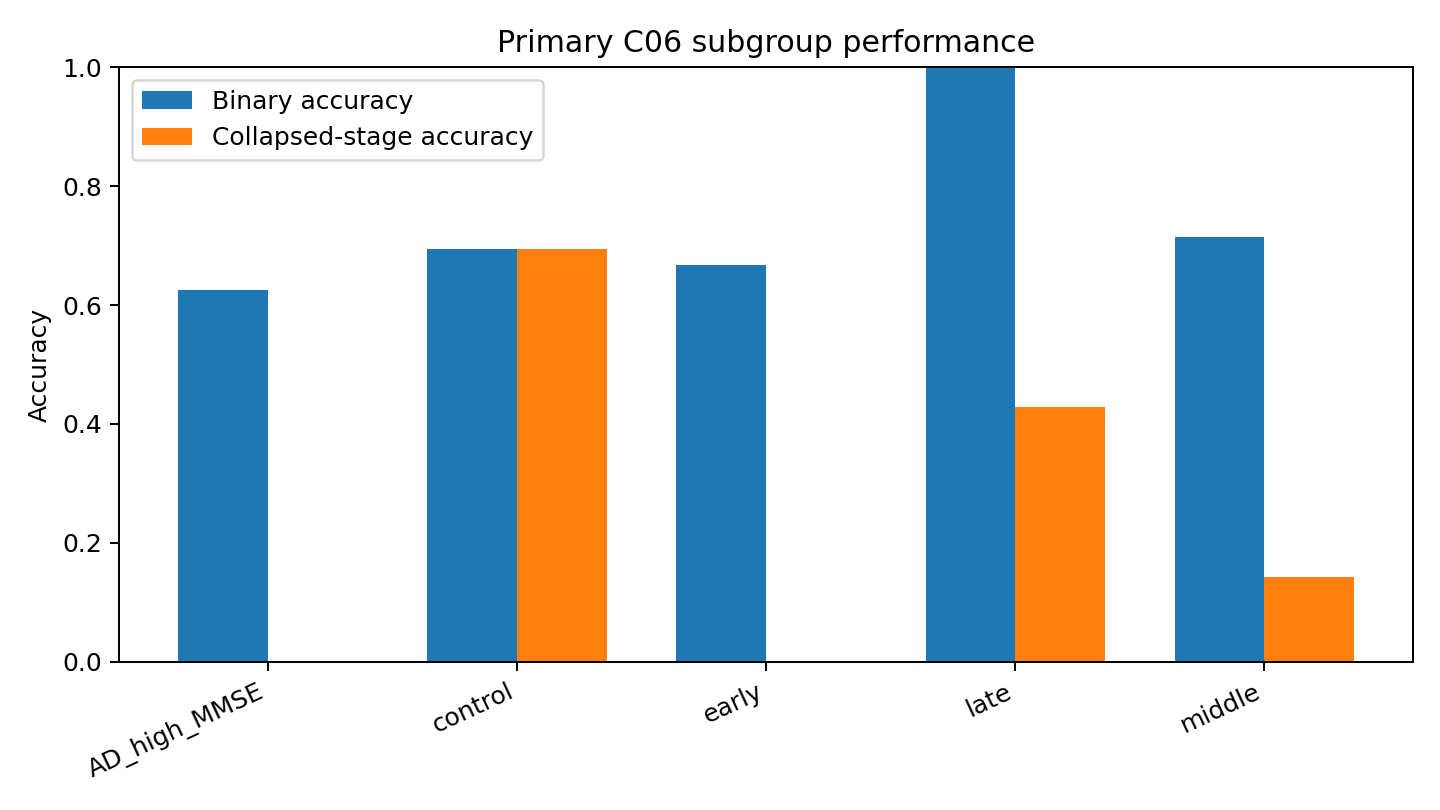

In [11]:
strict = read_csv('stagev7_final_stage_strict_audit.csv')
if not strict.empty:
    display(Markdown('**Strict audit retains `AD_high_MMSE` rather than relabelling it as strict early.**'))
    display(strict)

path_audit = read_csv('stagev7_gate_path_audit.csv')
if not path_audit.empty:
    display(path_audit)

errors = read_csv('stagev7_cascade_error_analysis.csv')
if not errors.empty:
    display_existing_columns(
        errors,
        ['sample_id', 'true_original_stage_label', 'true_collapsed_stage_label', 'predicted_stage', 'disease_label', 'predicted_AD', 'decision_path', 'late_gate_score', 'middle_gate_score_given_nonlate', 'early_spectrum_gate_score_given_nonlate_nonmiddle', 'ad_path_score', 'binary_correct', 'stage_correct_collapsed'],
        n=100,
    )
else:
    display(Markdown('No errors were recorded, or the final results have not been generated yet.'))
show_png('fig04_primary_stage_subgroup_accuracy.png', 'Primary C06 subgroup performance')

## 11. Leakage, reproducibility, and final audit conclusion

In [12]:
leakage = read_json('stagev7_leakage_check.json')
if leakage:
    display(pd.json_normalize(leakage))

summary = read_json('stagev7_final_run_summary.json')
if summary:
    display(pd.json_normalize(summary, sep='.'))

show_md('stagev7_experiment_report.md')

if not primary_perf.empty:
    conclusion = (
        'Stagev7 primary reporting is based on the pre-specified C06 cascade. '
        'The notebook renders existing artifacts only. External comparisons among the 20 fixed cascades are exploratory, '
        'and they must not be described as external-test model selection.'
    )
else:
    conclusion = (
        'The final training artifacts are not present yet. Run the stagev7 training command first; '
        'this notebook will then render the saved results without retraining.'
    )
display(Markdown(f'**Audit conclusion:** {conclusion}'))

,external_used_for_training_or_hyperparameter_selection,external_used_for_exploratory_evaluation_of_predefined_cascades,primary_cascade,primary_cascade_pre_specified,feature_extraction_re_run,api_calls,mmse_used_as_model_feature,feature_source
0,False,True,C06,True,False,False,False,strictly stagev5 generated E/M/L CSVs


,created_at,primary_cascade,n_predefined_cascades,bootstrap_n,n_jobs,flat_baseline_count,external_ranking_is_exploratory,primary_components.late,primary_components.middle,primary_components.early,...,primary_external_metrics.stage_weighted_f1,gate_metadata.late.n_train,gate_metadata.late.n_positive,gate_metadata.late.positive_definition,gate_metadata.middle.n_train,gate_metadata.middle.n_positive,gate_metadata.middle.positive_definition,gate_metadata.early.n_train,gate_metadata.early.n_positive,gate_metadata.early.positive_definition
0,2026-06-21T11:17:05.136238+00:00,C06,20,200,12,4,True,ML__lr__l2,EM__svc__poly3,EM__svc__poly3,...,0.415785,166,16,Late,150,50,Middle among non-late,100,21,Early + AD_high_MMSE among non-late/non-middle


# Stagev7 experiment report

## Design
Stagev7 is an ordered three-gate cascade: late vs non-late; middle vs remaining non-late; early-spectrum AD vs control among remaining samples.
All model inputs are copied E/M/L feature CSVs generated in stagev5. The run does not call an API or regenerate features.
## Selection
Each gate searches its bounded model panel using 10-fold stratified CV and balanced accuracy. C06 is the primary pre-specified cascade. Twenty fixed cascades plus four flat multiclass baselines are evaluated on the held-out external data for comparison.
## Interpretation restriction
External results are evaluation outcomes. Rankings across predefined cascades are labelled exploratory because several fixed candidate systems are compared on the same held-out set.


**Audit conclusion:** Stagev7 primary reporting is based on the pre-specified C06 cascade. The notebook renders existing artifacts only. External comparisons among the 20 fixed cascades are exploratory, and they must not be described as external-test model selection.